<a href="https://colab.research.google.com/github/chrisampiah/Content/blob/main/myelin_age_gap_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Myelin Brain Age Gap & Diagnosis Classifier
**Dataset:** Large dataset of infancy and early childhood brain MRIs (T1w and T2w)  
**Authors:** Akinci D'Antonoli et al. — Zenodo DOI: 10.5281/zenodo.8055666  

## Pipeline
```
Step 1 — Age Regression:   MRI (T1w + T2w) → age_pred
Step 2 — Gap Computation:  gap = age_pred − age
Step 3 — 3-class diagnosis (subjects where gap ≠ 0):
             Input:  [gap, age_pred, (optionally MRI features)]
             Output: normal | preterm | other
```

**Metrics reported:**
- Regression: MAE and RMSE between `age_pred` and `age` (age misestimation error)
- Classification: per-class accuracy, confusion matrix, and misclassification error for `preterm` vs all other diagnoses

> ⚠️ **Runtime:** Set to `T4 GPU` via Runtime → Change runtime type → GPU

## 1. Install dependencies

In [61]:
#pip install -q nibabel nilearn scikit-learn monai einops

## 2. Download the dataset from Zenodo

In [3]:
import os

DATA_DIR = "myelin_dataset"
os.makedirs(DATA_DIR, exist_ok=True)

# Download from Zenodo record 8055666
#!zenodo_get 10.5281/zenodo.8055666 -o {DATA_DIR}

!ls {DATA_DIR} | head -20

atlas
meta.csv
s0001
s0002
s0003
s0004
s0005
s0006
s0007
s0008
s0009
s0010
s0011
s0012
s0013
s0014
s0015
s0016
s0017
s0018


## 3. Inspect and prepare metadata

In [4]:
import pandas as pd
import glob
import numpy as np
import os

'''
# Check if the zip file exists and unzip it if it hasn't been already
zip_file_path = os.path.join(DATA_DIR, "zenodo_upload_v2.zip")
if os.path.exists(zip_file_path):
    print(f"Unzipping {zip_file_path}...")
    # Use -o to overwrite existing files, -q for quiet mode
    !unzip -o -q {zip_file_path} -d {DATA_DIR}
    print("Unzipping complete.")
else:
    print(f"Zip file not found at {zip_file_path}. Assuming data is already unzipped or not downloaded correctly.")
'''
meta_path = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)[0]
df = pd.read_csv(meta_path, sep=';') # Attempting to read with semicolon separator
df = df.dropna(subset=['age','age_corrected']).copy()
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (833, 7)
Columns: ['image_id', 'myelinisation', 'age', 'age_corrected', 'doctor_predicted_age', 'diagnosis', 'group']


,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
0,s0001,normal,22,22,22,normal,train
1,s0002,normal,29,29,29,normal,train
2,s0003,normal,4,4,4,normal,train
3,s0004,normal,0,0,0,normal,train
4,s0005,normal,0,0,0,normal,train


In [5]:

# GAP computation (correct definition)
df['gap'] = df['age'] - df['age_corrected']
df[['age','age_corrected','gap']].head()


,age,age_corrected,gap
0,22,22,0
1,29,29,0
2,4,4,0
3,0,0,0
4,0,0,0


In [6]:
# Inspect the diagnosis and age_pred columns
print("=== diagnosis distribution ===")
print(df['diagnosis'].value_counts())
print()
print("=== age_corrected sample ===")
print(df[['age', 'age_corrected']].describe())

=== diagnosis distribution ===
diagnosis
normal                             565
HIE                                 45
Hydrocephalus                       30
Infarct                             21
Meningitis                          17
                                  ... 
neuroectodermal tumor                1
cerebral atrophy, hydrocephalus      1
Normal                               1
Premature, PVL, Hydrocephalus        1
medulloblastoma                      1
Name: count, Length: 73, dtype: int64

=== age_corrected sample ===
              age  age_corrected
count  833.000000     833.000000
mean    13.722689      13.668667
std     11.754957      11.795154
min      0.000000      -1.000000
25%      3.000000       3.000000
50%     12.000000      12.000000
75%     24.000000      24.000000
max     36.000000      36.000000


## 4. Build file paths and filter subjects with both T1w + T2w

In [7]:
import os, glob

# Keep only subjects that have a valid age and age_pred
df = df.dropna(subset=['age', 'age_corrected']).copy()
print(f"Subjects with valid age/age_corrected: {len(df)}")

def find_nifti(subject_id, modality, data_dir):
    """Find a NIfTI file for a given subject and modality (t1 or t2)."""
    # Based on ls -R output, files are in <data_dir>/<subject_id>/<modality>.nii.gz
    path = os.path.join(data_dir, subject_id, f"{modality}.nii.gz")
    if os.path.exists(path):
        return path
    return None

# Detect the subject-id column
id_col = next(c for c in ['subject', 'subject_id', 'sub', 'id', 'SubjectID', 'image_id'] if c in df.columns)
print(f"Using ID column: {id_col}")

# --- Add this for debugging file structure ---
print(f"\nListing contents of {DATA_DIR} to debug NIfTI file paths:")
!ls -R {DATA_DIR}
print("-" * 50)
# ---------------------------------------------

t1_paths, t2_paths, valid_idx = [], [], []
for i, row in df.iterrows():
    sid = str(row[id_col])
    # Changed 'T1w' to 't1' and 'T2w' to 't2' based on file names
    t1 = find_nifti(sid, 't1', DATA_DIR)
    t2 = find_nifti(sid, 't2', DATA_DIR)
    if t1 and t2:
        t1_paths.append(t1)
        t2_paths.append(t2)
        valid_idx.append(i)

df_valid = df.loc[valid_idx].copy()
df_valid['t1_path'] = t1_paths
df_valid['t2_path'] = t2_paths
print(f"Subjects with both T1w + T2w found: {len(df_valid)}")

Subjects with valid age/age_corrected: 833
Using ID column: image_id

Listing contents of myelin_dataset to debug NIfTI file paths:
myelin_dataset:
atlas	  s0075  s0151	s0227  s0303  s0379  s0455  s0531  s0607  s0683  s0759
meta.csv  s0076  s0152	s0228  s0304  s0380  s0456  s0532  s0608  s0684  s0760
s0001	  s0077  s0153	s0229  s0305  s0381  s0457  s0533  s0609  s0685  s0761
s0002	  s0078  s0154	s0230  s0306  s0382  s0458  s0534  s0610  s0686  s0762
s0003	  s0079  s0155	s0231  s0307  s0383  s0459  s0535  s0611  s0687  s0763
s0004	  s0080  s0156	s0232  s0308  s0384  s0460  s0536  s0612  s0688  s0764
s0005	  s0081  s0157	s0233  s0309  s0385  s0461  s0537  s0613  s0689  s0765
s0006	  s0082  s0158	s0234  s0310  s0386  s0462  s0538  s0614  s0690  s0766
s0007	  s0083  s0159	s0235  s0311  s0387  s0463  s0539  s0615  s0691  s0767
s0008	  s0084  s0160	s0236  s0312  s0388  s0464  s0540  s0616  s0692  s0768
s0009	  s0085  s0161	s0237  s0313  s0389  s0465  s0541  s0617  s0693  s0769
s0010	  s0086 

--------------------------------------------------
Subjects with both T1w + T2w found: 833


## 5. MONAI transforms — resize + normalise 3-D volumes

In [9]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, Orientationd, ScaleIntensityRangePercentilesd,
    Resized, ConcatItemsd, ToTensord
)

TARGET_SHAPE = (64, 64, 64)   # Reduce if OOM; increase for better accuracy

mri_transforms = Compose([
    LoadImaged(keys=['t1', 't2']),
    EnsureChannelFirstd(keys=['t1', 't2']),
    Orientationd(keys=['t1', 't2'], axcodes='RAS'),
    Spacingd(keys=['t1', 't2'], pixdim=(2.0, 2.0, 2.0), mode='bilinear'),
    ScaleIntensityRangePercentilesd(keys=['t1', 't2'], lower=1, upper=99,
                                     b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=['t1', 't2'], spatial_size=TARGET_SHAPE),
    ConcatItemsd(keys=['t1', 't2'], name='image', dim=0),  # → (2, D, H, W)
    ToTensord(keys=['image'])
])

## 6. Dataset and DataLoaders — Step 1: Age Regression
Target: `age_pred` column (the expert-assigned or model-predicted brain age from the dataset).

In [68]:
'''
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class AgeRegressionDataset(Dataset):
    """
    Returns (image, age_corrected) pairs.
    The model learns to predict age_corrected from raw MRI.
    """
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data_dict = {'t1': row['t1_path'], 't2': row['t2_path']}
        data_dict = self.transforms(data_dict)
        image    = data_dict['image']                              # (2, D, H, W)
        age_pred = torch.tensor(row['age_corrected'], dtype=torch.float32)
        return image, age_pred

# 70/15/15 split (no stratification needed for regression)
train_df, test_df = train_test_split(df_valid, test_size=0.30, random_state=42)
val_df,   test_df = train_test_split(test_df,  test_size=0.50, random_state=42)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

BATCH = 4
train_reg_ds = AgeRegressionDataset(train_df, mri_transforms)
val_reg_ds   = AgeRegressionDataset(val_df,   mri_transforms)
test_reg_ds  = AgeRegressionDataset(test_df,  mri_transforms)

train_reg_loader = DataLoader(train_reg_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_reg_loader   = DataLoader(val_reg_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_reg_loader  = DataLoader(test_reg_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
'''
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler, Dataset, DataLoader
import pandas as pd, numpy as np, torch

AGE_BINS   = [-2, 0, 3, 6, 9, 12, 18, 24, 30, 37]
N_REPEATS  = 1  # increase to 20 when ready
TEST_SIZE  = 0.20
SEEDS      = list(range(N_REPEATS))
BATCH      = 4

class AgeRegressionDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data_dict = self.transforms({'t1': row['t1_path'], 't2': row['t2_path']})
        image    = data_dict['image']
        age_pred = torch.tensor(row['age_corrected'], dtype=torch.float32)
        return image, age_pred

def make_strat_key(df):
    df = df.copy()
    df['_age_bin'] = pd.cut(df['age_corrected'], bins=AGE_BINS,
                             right=False, labels=False).astype(str)
    def broad(d):
        d = str(d).lower()
        if d == 'normal':    return 'normal'
        if 'premature' in d: return 'preterm'
        return 'other'
    df['_diag'] = df['diagnosis'].apply(broad)
    df['_key']  = df['_age_bin'] + '_' + df['_diag']
    counts = df['_key'].value_counts()
    rare   = counts[counts < 2].index
    df['_key'] = df['_key'].where(~df['_key'].isin(rare), other='rare')
    return df

def make_sampler(train_df):
    bin_counts     = train_df['_bin'].value_counts()
    sample_weights = train_df['_bin'].map(1.0 / bin_counts).values
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(train_df),
        replacement=True
    )

df_keyed   = make_strat_key(df_valid)
all_results = []

print(f"Dataset ready: {len(df_keyed)} subjects, {N_REPEATS} seed(s), test size {TEST_SIZE}")

Dataset ready: 833 subjects, 1 seed(s), test size 0.2


## 7. Model — 3D ResNet-18 for Age Regression (1 output neuron)

In [11]:
import torch.nn as nn
from monai.networks.nets import resnet18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class AgeRegressor(nn.Module):
    """ResNet-18 backbone with a single scalar regression head."""
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(
            pretrained=False,
            spatial_dims=3,
            n_input_channels=2,   # T1w + T2w
            num_classes=1          # regression → scalar
        )
    def forward(self, x):
        return self.backbone(x).squeeze(1)  # → (B,)

reg_model = AgeRegressor().to(device)
print(f"Parameters: {sum(p.numel() for p in reg_model.parameters()):,}")

Using device: cuda
Parameters: 33,183,361


## 8. Loss, optimiser, scheduler — Regression

In [70]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
'''
reg_criterion = nn.MSELoss()                           # MSE = RMSE² ; we also track MAE
reg_optimizer = AdamW(reg_model.parameters(), lr=1e-4, weight_decay=1e-5)
reg_scheduler = CosineAnnealingLR(reg_optimizer, T_max=30, eta_min=1e-6)
'''
import numpy as np

class AgeWeightedLoss(nn.Module):
    def __init__(self, age_bins, bin_counts_dict, mse_weight=0.5, rank_weight=0.3):
        super().__init__()
        self.mse_weight  = mse_weight
        self.rank_weight = rank_weight
        n_bins = len(age_bins) - 1
        raw = np.array([1.0 / bin_counts_dict.get(i, 1) for i in range(n_bins)],
                       dtype=np.float32)
        raw = raw / raw.mean()
        self.register_buffer('bin_weights', torch.FloatTensor(raw))
        self.register_buffer('boundaries', torch.FloatTensor(age_bins[1:-1]))

    def forward(self, preds, targets):
        # --- weighted MAE + MSE ---
        bin_idx = torch.bucketize(targets, self.boundaries)
        bin_idx = bin_idx.clamp(0, len(self.bin_weights) - 1)
        w   = self.bin_weights[bin_idx]
        mae = torch.abs(preds - targets).mean()
        mse = (w * (preds - targets) ** 2).mean()

        # --- ranking loss ---
        # for every pair (i,j) where target_i > target_j by at least 3 months,
        # penalise if pred_i <= pred_j  (model got the order wrong)
        t_diff = targets.unsqueeze(1) - targets.unsqueeze(0)   # (B, B)
        p_diff = preds.unsqueeze(1)   - preds.unsqueeze(0)     # (B, B)
        margin = 1.5 # 3.0   # months — only penalise clear age differences
        pair_mask = t_diff > margin
        if pair_mask.sum() > 0:
            rank_loss = torch.clamp(margin - p_diff[pair_mask], min=0).mean()
        else:
            rank_loss = torch.tensor(0.0, device=preds.device)

        return mae + self.mse_weight * mse + self.rank_weight * rank_loss

## 9. Training loop — Step 1: MRI → age_corrected

In [72]:
'''
EPOCHS_REG = 20
SAVE_REG   = "best_age_regressor_doc.pth"

reg_history = {'train_mse': [], 'val_mae': [], 'val_rmse': []}
best_val_mae = float('inf')

def run_reg_epoch(loader, training=True):
    reg_model.train() if training else reg_model.eval()
    total_mse = 0.0
    all_preds, all_targets = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            preds = reg_model(images)
            loss  = reg_criterion(preds, targets)
            if training:
                reg_optimizer.zero_grad()
                loss.backward()
                reg_optimizer.step()
            total_mse  += loss.item() * len(targets)
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)
    mae  = np.mean(np.abs(all_preds - all_targets))
    rmse = np.sqrt(total_mse / len(loader.dataset))
    return mae, rmse, all_preds, all_targets

for epoch in range(1, EPOCHS_REG + 1):
    tr_mae, tr_rmse, _, _ = run_reg_epoch(train_reg_loader, training=True)
    vl_mae, vl_rmse, _, _ = run_reg_epoch(val_reg_loader,   training=False)
    reg_scheduler.step()

    reg_history['train_mse'].append(tr_rmse**2)
    reg_history['val_mae'].append(vl_mae)
    reg_history['val_rmse'].append(vl_rmse)

    if vl_mae < best_val_mae:
        best_val_mae = vl_mae
        torch.save(reg_model.state_dict(), SAVE_REG)
        flag = " ✓ saved"
    else:
        flag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS_REG} | "
          f"Train RMSE {tr_rmse:.3f} | "
          f"Val MAE {vl_mae:.3f}  Val RMSE {vl_rmse:.3f}{flag}")
'''
EPOCHS_REG = 50
all_results = []   # accumulates one dict per seed
ACCUM_STEPS = 4

def run_reg_epoch(loader, training=True):
    reg_model.train() if training else reg_model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for step, (images, targets) in enumerate(loader):
            images, targets = images.to(device), targets.to(device)
            preds = reg_model(images)
            loss  = reg_criterion(preds, targets)

            if training:
                loss = loss / ACCUM_STEPS        # scale loss
                loss.backward()
                if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(loader):
                    reg_optimizer.step()
                    reg_optimizer.zero_grad()

            total_loss += loss.item() * len(targets) * (ACCUM_STEPS if training else 1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)
    mae  = np.mean(np.abs(all_preds - all_targets))
    rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
    return mae, rmse, all_preds, all_targets


for seed in SEEDS:
    print(f"\n{'='*55}")
    print(f"  SEED {seed:02d} / {SEEDS[-1]:02d}")
    print(f"{'='*55}")

    # --- split ---
    train_df, test_df = train_test_split(
        df_keyed,
        test_size=TEST_SIZE,
        stratify=df_keyed['_key'],
        random_state=seed
    )
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    

    # --- sampler ---
    train_df['_bin'] = pd.cut(train_df['age_corrected'], bins=AGE_BINS,
                               right=False, labels=False)
    
    sampler = make_sampler(train_df)

    # --- dataloaders ---
    train_ds = AgeRegressionDataset(train_df, mri_transforms)
    test_ds  = AgeRegressionDataset(test_df,  mri_transforms)

    train_reg_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                                  num_workers=2, pin_memory=True)
    test_reg_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                                  num_workers=2, pin_memory=True)

    # --- fresh model, loss, optimiser, scheduler for this seed ---
    # --- fresh model, loss, optimiser, scheduler for this seed ---
    reg_model     = AgeRegressor().to(device)
    reg_criterion = AgeWeightedLoss(
        AGE_BINS,
        train_df['_bin'].value_counts().to_dict(),
        mse_weight=0.5,
        rank_weight=0.5       # up from 0.3 — rank loss needs more weight
                               # since it fires rarely with small batches
    ).to(device)
    reg_optimizer = AdamW(reg_model.parameters(), lr=1e-4, weight_decay=1e-5)
    reg_scheduler = CosineAnnealingLR(reg_optimizer, T_max=EPOCHS_REG, eta_min=1e-6)
    # --- training ---
    best_train_mae = float('inf')
    save_path = f"best_regressor_seed{seed:02d}.pth"

    reg_history = {'train_mae': [], 'train_rmse': []}

    reg_optimizer.zero_grad() 
    for epoch in range(1, EPOCHS_REG + 1):
        tr_mae, tr_rmse, _, _ = run_reg_epoch(train_reg_loader, training=True)
        te_mae_ep, te_rmse_ep, _, _ = run_reg_epoch(test_reg_loader, training=False)
        reg_scheduler.step()

        reg_history['train_mae'].append(tr_mae)
        reg_history['train_rmse'].append(tr_rmse)
        reg_history.setdefault('test_mae',  []).append(te_mae_ep)
        reg_history.setdefault('test_rmse', []).append(te_rmse_ep)

        if tr_mae < best_train_mae:
            best_train_mae = tr_mae
            torch.save(reg_model.state_dict(), save_path)
            flag = " ✓ saved"
        else:
            flag = ""

        print(f"  Epoch {epoch:02d}/{EPOCHS_REG} | "
              f"Train MAE {tr_mae:.3f}  RMSE {tr_rmse:.3f} | "
              f"Test MAE {te_mae_ep:.3f}  RMSE {te_rmse_ep:.3f}{flag}")

    # reload best weights before evaluation in Section 11
    reg_model.load_state_dict(torch.load(save_path, map_location=device))


  SEED 00 / 00
  Epoch 01/50 | Train MAE 9.290  RMSE 12.906 | Test MAE 7.173  RMSE 10.295 ✓ saved
  Epoch 02/50 | Train MAE 6.926  RMSE 9.524 | Test MAE 4.915  RMSE 7.128 ✓ saved
  Epoch 03/50 | Train MAE 6.063  RMSE 8.684 | Test MAE 3.864  RMSE 4.879 ✓ saved
  Epoch 04/50 | Train MAE 5.656  RMSE 8.068 | Test MAE 8.086  RMSE 10.880 ✓ saved
  Epoch 05/50 | Train MAE 4.576  RMSE 6.721 | Test MAE 2.953  RMSE 4.110 ✓ saved
  Epoch 06/50 | Train MAE 3.977  RMSE 5.867 | Test MAE 6.860  RMSE 9.308 ✓ saved
  Epoch 07/50 | Train MAE 4.146  RMSE 6.069 | Test MAE 2.493  RMSE 3.675
  Epoch 08/50 | Train MAE 3.206  RMSE 4.937 | Test MAE 2.849  RMSE 4.285 ✓ saved
  Epoch 09/50 | Train MAE 2.628  RMSE 3.985 | Test MAE 2.982  RMSE 4.412 ✓ saved
  Epoch 10/50 | Train MAE 3.445  RMSE 4.972 | Test MAE 2.740  RMSE 3.974
  Epoch 11/50 | Train MAE 2.664  RMSE 3.994 | Test MAE 2.467  RMSE 3.529
  Epoch 12/50 | Train MAE 2.447  RMSE 3.648 | Test MAE 2.665  RMSE 3.594 ✓ saved
  Epoch 13/50 | Train MAE 2.369  

/tmp/ipykernel_6846/3452283345.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reg_model.load_state_dict(torch.load(save_path, map_location=device))


## 10. Training curves — Regression

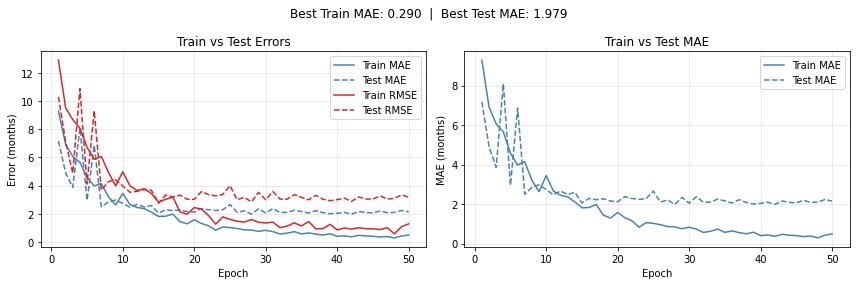

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(reg_history['train_mae']) + 1)

axes[0].plot(ep, reg_history['train_mae'],  label='Train MAE',  color='steelblue')
axes[0].plot(ep, reg_history['test_mae'],   label='Test MAE',   color='steelblue', linestyle='--')
axes[0].plot(ep, reg_history['train_rmse'], label='Train RMSE', color='tab:red')
axes[0].plot(ep, reg_history['test_rmse'],  label='Test RMSE',  color='tab:red',   linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Error (months)')
axes[0].set_title('Train vs Test Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, reg_history['train_mae'], label='Train MAE', color='steelblue')
axes[1].plot(ep, reg_history['test_mae'],  label='Test MAE',  color='steelblue', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (months)')
axes[1].set_title('Train vs Test MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Best Train MAE: {min(reg_history["train_mae"]):.3f}  |  '
             f'Best Test MAE: {min(reg_history["test_mae"]):.3f}')
plt.tight_layout()
plt.savefig('reg_training_curves.png', dpi=120)
plt.show()

## 11. Step 2: Compute gap = age_pred − age on the test set
We reload the best regression model, run inference on the **full dataset** to collect model-predicted ages, then compute the brain-age gap.

In [93]:
'''
# ---- Reload best regressor ----
reg_model.load_state_dict(torch.load(SAVE_REG, map_location=device))
reg_model.eval()

# Run on full dataset to collect model-predicted ages for all subjects
# (needed to build the gap-based feature set for Step 3)
from torch.utils.data import Dataset, DataLoader

class FullDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        d   = self.transforms({'t1': row['t1_path'], 't2': row['t2_path']})
        return d['image'], torch.tensor(row['age_corrected'], dtype=torch.float32)

full_loader = DataLoader(
    FullDataset(df_valid, mri_transforms),
    batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True
)

model_age_preds, true_ages = [], []
with torch.no_grad():
    for images, ages in full_loader:
        preds = reg_model(images.to(device)).cpu().numpy()
        model_age_preds.extend(preds)
        true_ages.extend(ages.numpy())

model_age_preds = np.array(model_age_preds)
true_ages       = np.array(true_ages)
gaps            = model_age_preds - true_ages

df_valid = df_valid.copy()
df_valid['model_age_pred'] = model_age_preds  # our CNN's prediction
df_valid['gap']            = gaps

print("Gap statistics:")
print(pd.Series(gaps).describe())

# ---- Regression error between our model's age_pred and chronological age ----
mae_overall  = np.mean(np.abs(model_age_preds - true_ages))
rmse_overall = np.sqrt(np.mean((model_age_preds - true_ages)**2))
print(f"\n=== Age Prediction Error (Step 1) ===")
print(f"  MAE  (age_corrected vs age): {mae_overall:.4f}")
print(f"  RMSE (age_corrected vs age): {rmse_overall:.4f}")
'''
# =====================================================================
# SECTION 11 — Evaluation, gap computation, summary
# =====================================================================

reg_model.eval()
te_mae, te_rmse, model_age_preds, true_ages = run_reg_epoch(
    test_reg_loader, training=False
)
gaps = model_age_preds - true_ages

# --- bias correction ---
bias = np.mean(model_age_preds - true_ages)
print(f"Systematic bias: {bias:.3f} months")

model_age_preds_corrected = model_age_preds - bias
gaps_corrected = model_age_preds_corrected - true_ages

mae_corrected = np.mean(np.abs(model_age_preds_corrected - true_ages))
print(f"MAE before correction: {te_mae:.3f}")
print(f"MAE after  correction: {mae_corrected:.3f}")

model_age_preds = model_age_preds_corrected
gaps            = gaps_corrected

test_df = test_df.copy()
test_df['model_age_pred'] = model_age_preds
test_df['gap']            = gaps

group_mae = {}
for grp in ['normal', 'preterm', 'other']:
    mask = test_df['_diag'].values == grp
    group_mae[grp] = float(np.mean(np.abs(
        model_age_preds[mask] - true_ages[mask]
    ))) if mask.sum() > 0 else float('nan')

print(f"\nLast seed TEST results")
print(f"MAE  : {te_mae:.4f}  |  RMSE : {te_rmse:.4f}")
print(f"MAE normal  : {group_mae['normal']:.4f}")
print(f"MAE preterm : {group_mae['preterm']:.4f}")
print(f"MAE other   : {group_mae['other']:.4f}")

from scipy.stats import pearsonr, spearmanr
r_pearson,  p_p = pearsonr(true_ages, model_age_preds)
r_spearman, p_s = spearmanr(true_ages, model_age_preds)
print(f"\nPearson  r = {r_pearson:.3f}  (p={p_p:.2e})")
print(f"Spearman r = {r_spearman:.3f}  (p={p_s:.2e})")
print(f"R²         = {r_pearson**2:.3f}")

best_result = {
    'seed'           : SEEDS[-1],
    'mae'            : te_mae,
    'rmse'           : te_rmse,
    'mae_normal'     : group_mae['normal'],
    'mae_preterm'    : group_mae['preterm'],
    'mae_other'      : group_mae['other'],
    'test_df'        : test_df,
    'model_age_preds': model_age_preds,
    'true_ages'      : true_ages,
    'save_path'      : save_path,
}

results_df = pd.DataFrame([{k: v for k, v in best_result.items()
                             if k not in ('test_df', 'model_age_preds',
                                          'true_ages', 'save_path')}])
print("\n--- summary ---")
print(results_df[['seed','mae','rmse','mae_normal','mae_preterm','mae_other']]
      .to_string(index=False))

# reload best weights
reg_model.load_state_dict(torch.load(best_result['save_path'], map_location=device))
test_df_best = best_result['test_df']
mae_overall  = best_result['mae']
rmse_overall = best_result['rmse']

# --- run inference on ALL df_valid (needed for classifier in Sections 30-31) ---
full_loader = DataLoader(
    FullDataset(df_valid, mri_transforms),
    batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True
)

reg_model.eval()
all_preds_full = []
with torch.no_grad():
    for images, _ in full_loader:
        preds = reg_model(images.to(device)).cpu().numpy()
        all_preds_full.extend(preds)

all_preds_full = np.array(all_preds_full) - bias

df_valid = df_valid.copy()
df_valid['model_age_pred'] = all_preds_full
df_valid['gap']            = all_preds_full - df_valid['age_corrected'].values

# keep test-set variables for scatter plot in Section 26
model_age_preds = best_result['model_age_preds']
true_ages       = best_result['true_ages']
gaps            = model_age_preds - true_ages

print(f"\nFull df_valid predictions: {len(all_preds_full)} subjects")
print(f"NaNs in gap: {df_valid['gap'].isna().sum()}")

Systematic bias: -0.889 months
MAE before correction: 2.100
MAE after  correction: 2.216

Last seed TEST results
MAE  : 2.0999  |  RMSE : 3.0914
MAE normal  : 2.3511
MAE preterm : 1.0479
MAE other   : 2.0167

Pearson  r = 0.972  (p=3.61e-106)
Spearman r = 0.973  (p=2.36e-106)
R²         = 0.945

--- summary ---
 seed      mae     rmse  mae_normal  mae_preterm  mae_other
    0 2.099899 3.091436    2.351113     1.047876   2.016745


/tmp/ipykernel_6846/3876898945.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reg_model.load_state_dict(torch.load(best_result['save_path'], map_location=device))



Full df_valid predictions: 833 subjects
NaNs in gap: 0


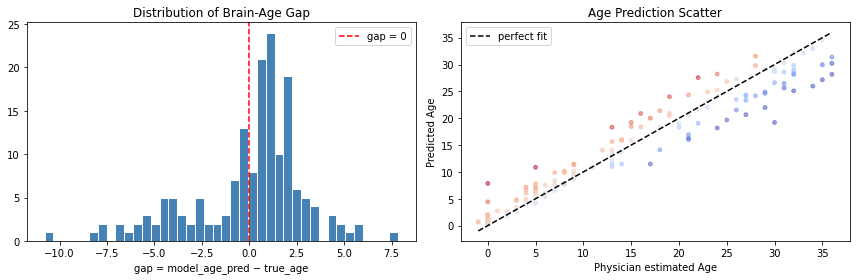

In [78]:
# Visualise the gap distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gaps, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='gap = 0')
axes[0].set_xlabel('gap = model_age_pred − true_age')
axes[0].set_title('Distribution of Brain-Age Gap')
axes[0].legend()

axes[1].scatter(true_ages, model_age_preds, alpha=0.5, s=15, c=gaps,
                cmap='coolwarm', vmin=-np.percentile(np.abs(gaps), 95),
                vmax=np.percentile(np.abs(gaps), 95))
axes[1].plot([true_ages.min(), true_ages.max()],
             [true_ages.min(), true_ages.max()], 'k--', label='perfect fit')
axes[1].set_xlabel('Physician estimated Age'); axes[1].set_ylabel('Predicted Age')
axes[1].set_title('Age Prediction Scatter')
axes[1].legend()

plt.tight_layout()
plt.savefig('gap_analysis.png', dpi=120)
plt.show()

In [21]:
def assign_clf_label_v2(d):
    d = str(d).lower().strip()
    if 'premature' in d:         return 1   # preterm FIRST, before checking HIE/hydrocephalus
    if d == 'normal':            return 0
    if 'hie' in d or 'hypoxic' in d:  return 2
    if 'hydrocephal' in d:       return 3
    return -1

df_valid['label_clf'] = df_valid['diagnosis'].apply(assign_clf_label_v2)
df_clf = df_valid[df_valid['label_clf'] >= 0].copy().reset_index(drop=True)

print('=== Classifier dataset v2 ===')
print(df_clf['label_clf'].value_counts()
      .rename({0:'normal', 1:'preterm', 2:'HIE', 3:'hydrocephalus'}))
print(f'Total: {len(df_clf)}')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

df_stage1 = df_clf.copy()
df_stage1['is_preterm'] = (df_stage1['label_clf'] == 1).astype(int)

X_gap  = df_stage1[['gap']].values
y_gap  = df_stage1['is_preterm'].values

# align with the same train/test split used for the classifier
train_mask = df_stage1.index.isin(train_clf_df.index)
test_mask  = df_stage1.index.isin(test_clf_df.index)

X_tr_gap, y_tr_gap = X_gap[train_mask], y_gap[train_mask]
X_te_gap, y_te_gap = X_gap[test_mask],  y_gap[test_mask]

lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_tr_gap, y_tr_gap)

y_pred_gap = lr.predict(X_te_gap)
y_prob_gap = lr.predict_proba(X_te_gap)[:, 1]

print(classification_report(y_te_gap, y_pred_gap,
                             target_names=['not_preterm', 'preterm'],
                             zero_division=0))
print(f"AUC: {roc_auc_score(y_te_gap, y_prob_gap):.3f}")
print(f"\n⚠️  Preterm test subjects: {y_te_gap.sum()} — interpret with caution")

=== Classifier dataset v2 ===
label_clf
normal           566
HIE               50
hydrocephalus     32
preterm           27
Name: count, dtype: int64
Total: 675
              precision    recall  f1-score   support

 not_preterm       0.99      1.00      1.00       129
     preterm       1.00      0.83      0.91         6

    accuracy                           0.99       135
   macro avg       1.00      0.92      0.95       135
weighted avg       0.99      0.99      0.99       135

AUC: 0.917

⚠️  Preterm test subjects: 6 — interpret with caution


=== Classifier dataset ===
label_clf
normal           566
HIE               56
hydrocephalus     38
Name: count, dtype: int64
Total: 660

Train: 528  Test: 132
Train label dist: {'normal': 453, 'HIE': 45, 'hydrocephalus': 30}
Test  label dist: {'normal': 113, 'HIE': 11, 'hydrocephalus': 8}

Weights loaded — missing: ['backbone.fc.weight', 'backbone.fc.bias']  unexpected: []
Class weights: {'normal': 0.115, 'HIE': 1.154, 'hydrocephalus': 1.731}


/tmp/ipykernel_9040/2998457923.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reg_weights = torch.load('best_regressor_seed00.pth', map_location=device)


Epoch 01/15 | Train loss 0.347 acc 0.705 | Test loss 1.050 acc 0.356 ✓ saved
Epoch 02/15 | Train loss 0.247 acc 0.778 | Test loss 0.514 acc 0.773 ✓ saved
Epoch 03/15 | Train loss 0.129 acc 0.879 | Test loss 0.771 acc 0.598
Epoch 04/15 | Train loss 0.072 acc 0.928 | Test loss 0.587 acc 0.833 ✓ saved
Epoch 05/15 | Train loss 0.049 acc 0.945 | Test loss 1.063 acc 0.720
Epoch 06/15 | Train loss 0.070 acc 0.945 | Test loss 0.685 acc 0.795
Epoch 07/15 | Train loss 0.034 acc 0.973 | Test loss 0.497 acc 0.909 ✓ saved
Epoch 08/15 | Train loss 0.021 acc 0.987 | Test loss 0.626 acc 0.856
Epoch 09/15 | Train loss 0.025 acc 0.977 | Test loss 0.755 acc 0.720
Epoch 10/15 | Train loss 0.049 acc 0.962 | Test loss 0.634 acc 0.841
Epoch 11/15 | Train loss 0.010 acc 0.998 | Test loss 0.649 acc 0.871
Epoch 12/15 | Train loss 0.016 acc 0.989 | Test loss 0.648 acc 0.848
Epoch 13/15 | Train loss 0.007 acc 0.994 | Test loss 0.654 acc 0.879
Epoch 14/15 | Train loss 0.009 acc 0.992 | Test loss 0.762 acc 0.886
Ep

/tmp/ipykernel_9040/2998457923.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clf_model.load_state_dict(torch.load(SAVE_CLF, map_location=device))



=== Classification Report ===
               precision    recall  f1-score   support

       normal       0.97      0.92      0.95       113
          HIE       0.53      0.91      0.67        11
hydrocephalus       1.00      0.75      0.86         8

     accuracy                           0.91       132
    macro avg       0.83      0.86      0.82       132
 weighted avg       0.94      0.91      0.92       132

ROC-AUC (macro OvR): 0.9340


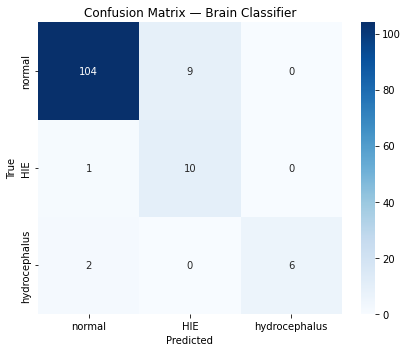

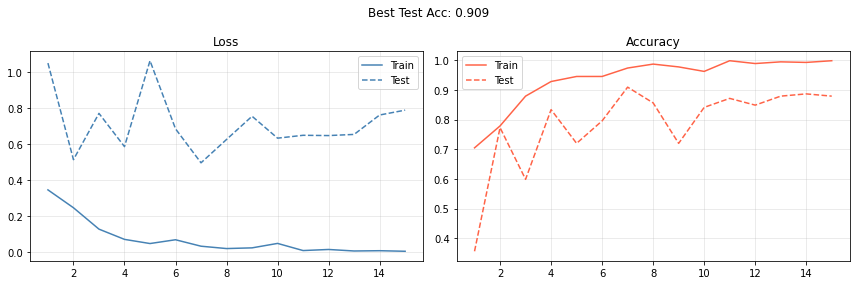

In [22]:
# =====================================================================
# BRAIN CLASSIFIER — normal / preterm / HIE / hydrocephalus
# Fine-tuned from best_age_regressor.pth
# =====================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from monai.networks.nets import resnet18
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. Label assignment ───────────────────────────────────────────────
CLASS_NAMES = ['normal', 'HIE', 'hydrocephalus']
NUM_CLASSES  = 3

def assign_clf_label(d):
    d = str(d).lower().strip()
    if d == 'normal':                          return 0
    if 'hie' in d or 'hypoxic' in d:          return 1
    if 'hydrocephal' in d:                     return 2
    return -1   # exclude preterm and everything else

df_valid['label_clf'] = df_valid['diagnosis'].apply(assign_clf_label)
df_clf = df_valid[df_valid['label_clf'] >= 0].copy().reset_index(drop=True)

print('=== Classifier dataset ===')
print(df_clf['label_clf'].value_counts()
      .rename({i: n for i, n in enumerate(CLASS_NAMES)}))
print(f'Total: {len(df_clf)}')

# ── 2. Stratified train / test split ─────────────────────────────────
# stratify by label so all 4 classes appear in both splits
train_clf_df, test_clf_df = train_test_split(
    df_clf,
    test_size=0.20,
    stratify=df_clf['label_clf'],
    random_state=42
)
train_clf_df = train_clf_df.reset_index(drop=True)
test_clf_df  = test_clf_df.reset_index(drop=True)

print(f'\nTrain: {len(train_clf_df)}  Test: {len(test_clf_df)}')
print('Train label dist:', train_clf_df['label_clf'].value_counts()
      .rename({i: n for i, n in enumerate(CLASS_NAMES)}).to_dict())
print('Test  label dist:', test_clf_df['label_clf'].value_counts()
      .rename({i: n for i, n in enumerate(CLASS_NAMES)}).to_dict())

# ── 3. Dataset ────────────────────────────────────────────────────────
class ClfDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        d   = self.transforms({'t1': row['t1_path'], 't2': row['t2_path']})
        img = d['image']
        lbl = torch.tensor(row['label_clf'], dtype=torch.long)
        return img, lbl

# ── 4. Weighted sampler (handles class imbalance in training) ─────────
from torch.utils.data import WeightedRandomSampler

label_counts  = train_clf_df['label_clf'].value_counts()
sample_weights = train_clf_df['label_clf'].map(1.0 / label_counts).values
clf_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_clf_df),
    replacement=True
)

BATCH_CLF = 4
train_clf_loader = DataLoader(
    ClfDataset(train_clf_df, mri_transforms),
    batch_size=BATCH_CLF, sampler=clf_sampler,
    num_workers=2, pin_memory=True
)
test_clf_loader = DataLoader(
    ClfDataset(test_clf_df, mri_transforms),
    batch_size=BATCH_CLF, shuffle=False,
    num_workers=2, pin_memory=True
)

# ── 5. Model — ResNet18 initialised from regressor backbone ──────────
class BrainClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = resnet18(
            pretrained=False,
            spatial_dims=3,
            n_input_channels=2,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.backbone(x)   # (B, num_classes) logits

clf_model = BrainClassifier(num_classes=NUM_CLASSES).to(device)

# load regressor weights — strict=False skips the final FC
# (regressor FC: 1 output, classifier FC: 4 outputs — shapes differ)
reg_weights = torch.load('best_regressor_seed00.pth', map_location=device)

# remove the regression head — shapes are incompatible (1 vs 4 outputs)
reg_weights.pop('backbone.fc.weight', None)
reg_weights.pop('backbone.fc.bias',   None)


missing, unexpected = clf_model.load_state_dict(reg_weights, strict=False)
print(f'\nWeights loaded — missing: {missing}  unexpected: {unexpected}')

# ── 6. Loss with class weights ────────────────────────────────────────
counts      = np.bincount(train_clf_df['label_clf'], minlength=NUM_CLASSES).astype(float)
cls_weights = torch.FloatTensor(1.0 / counts).to(device)
cls_weights = cls_weights / cls_weights.mean()   # normalise to mean=1
print('Class weights:', dict(zip(CLASS_NAMES, cls_weights.cpu().numpy().round(3))))

clf_criterion = nn.CrossEntropyLoss(weight=cls_weights)
clf_optimizer = AdamW(clf_model.parameters(), lr=5e-5, weight_decay=1e-4)

EPOCHS_CLF    = 15
clf_scheduler = CosineAnnealingLR(clf_optimizer, T_max=EPOCHS_CLF, eta_min=1e-6)
SAVE_CLF      = 'best_brain_classifier.pth'

# ── 7. Training loop ──────────────────────────────────────────────────
def run_clf_epoch(loader, training=True):
    clf_model.train() if training else clf_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = clf_model(images)
            loss   = clf_criterion(logits, labels)
            if training:
                clf_optimizer.zero_grad()
                loss.backward()
                clf_optimizer.step()
            probs  = torch.softmax(logits, dim=1)
            preds  = torch.argmax(probs, dim=1)
            total_loss += loss.item() * len(labels)
            correct    += (preds == labels).sum().item()
            total      += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
    acc = correct / total
    avg_loss = total_loss / total
    return avg_loss, acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)

clf_history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_test_acc = 0.0

clf_optimizer.zero_grad()

for epoch in range(1, EPOCHS_CLF + 1):
    tr_loss, tr_acc, _, _, _ = run_clf_epoch(train_clf_loader, training=True)
    te_loss, te_acc, _, _, _ = run_clf_epoch(test_clf_loader,  training=False)
    clf_scheduler.step()

    clf_history['train_loss'].append(tr_loss)
    clf_history['train_acc'].append(tr_acc)
    clf_history['test_loss'].append(te_loss)
    clf_history['test_acc'].append(te_acc)

    if te_acc > best_test_acc:
        best_test_acc = te_acc
        torch.save(clf_model.state_dict(), SAVE_CLF)
        flag = ' ✓ saved'
    else:
        flag = ''

    print(f'Epoch {epoch:02d}/{EPOCHS_CLF} | '
          f'Train loss {tr_loss:.3f} acc {tr_acc:.3f} | '
          f'Test loss {te_loss:.3f} acc {te_acc:.3f}{flag}')

# ── 8. Final evaluation with best weights ────────────────────────────
clf_model.load_state_dict(torch.load(SAVE_CLF, map_location=device))
_, _, all_preds, all_labels, all_probs = run_clf_epoch(test_clf_loader, training=False)

print('\n=== Classification Report ===')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, zero_division=0))

try:
    auc = roc_auc_score(all_labels, all_probs,
                        multi_class='ovr', average='macro')
    print(f'ROC-AUC (macro OvR): {auc:.4f}')
except Exception as e:
    print(f'AUC could not be computed: {e}')

# ── 9. Confusion matrix ───────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Brain Classifier')
plt.tight_layout()
plt.savefig('confusion_matrix_clf.png', dpi=120)
plt.show()

# ── 10. Training curves ───────────────────────────────────────────────
ep = range(1, EPOCHS_CLF + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ep, clf_history['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep, clf_history['test_loss'],  label='Test',  color='steelblue', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, clf_history['train_acc'],  label='Train', color='tomato')
axes[1].plot(ep, clf_history['test_acc'],   label='Test',  color='tomato',    linestyle='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f'Best Test Acc: {best_test_acc:.3f}')
plt.tight_layout()
plt.savefig('clf_training_curves.png', dpi=120)
plt.show()

## 12. Step 3: Assign 3-class diagnosis labels
```
normal    → diagnosis == 'normal'  AND  gap ≈ 0
premature → 'preterm' in diagnosis column
other     → everything else (polymicrogyria, HIE, etc.)
```

In [80]:
from scipy.stats import pearsonr, spearmanr

r_pearson,  p_p = pearsonr(true_ages, model_age_preds)
r_spearman, p_s = spearmanr(true_ages, model_age_preds)

print(f"Pearson  r = {r_pearson:.3f}  (p={p_p:.2e})")
print(f"Spearman r = {r_spearman:.3f}  (p={p_s:.2e})")
print(f"R²         = {r_pearson**2:.3f}")
print(f"MAE        = {te_mae:.3f} months")

Pearson  r = 0.972  (p=3.61e-106)
Spearman r = 0.973  (p=2.36e-106)
R²         = 0.945
MAE        = 2.100 months


In [2]:
def assign_3class_label(row):
    """
    Returns:
      0 = normal
      1 = preterm  (diagnosis contains 'preterm')
      2 = other      (any pathological diagnosis that is not preterm)
    """
    diag = str(row.get('diagnosis', '')).lower().strip()
    if 'preterm' in diag:
        return 1   # preterm
    elif diag == 'normal':
        return 0   # normal
    else:
        return 2   # other pathology (HIE, polymicrogyria, …)

df_valid['label3'] = df_valid.apply(assign_3class_label, axis=1)

label_names = {0: 'normal', 1: 'preterm', 2: 'other'}
print("3-class label distribution:")
print(df_valid['label3'].map(label_names).value_counts())

NameError: name 'df_valid' is not defined

## 13. Dataset and DataLoader — Step 3: Diagnosis Classifier
Input features: **[gap, model_age_pred]** + a flattened global-average-pooled MRI feature vector extracted from the frozen regression backbone.

In [95]:
class FullDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        d   = self.transforms({'t1': row['t1_path'], 't2': row['t2_path']})
        return d['image'], torch.tensor(row['age_corrected'], dtype=torch.float32)

reg_model.eval()
mri_features_list = []

def hook_fn(module, input, output):
    mri_features_list.append(output.detach().cpu().squeeze(-1).squeeze(-1).squeeze(-1))

hook = reg_model.backbone.avgpool.register_forward_hook(hook_fn)

feature_loader = DataLoader(
    FullDataset(df_valid, mri_transforms),
    batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True
)

mri_features_list.clear()  # 

with torch.no_grad():
    for images, _ in feature_loader:
        reg_model(images.to(device))

hook.remove()
mri_feats = torch.cat(mri_features_list, dim=0).numpy()
print(f"MRI feature matrix shape: {mri_feats.shape}")  # should print (833, 512)

MRI feature matrix shape: (833, 512)


In [96]:
# Combine tabular features [gap, model_age_pred] with MRI embedding
gap_feat       = df_valid['gap'].values.reshape(-1, 1)
age_pred_feat  = df_valid['model_age_pred'].values.reshape(-1, 1)
X_all          = np.hstack([gap_feat, age_pred_feat, mri_feats])  # (N, 2 + C)
y_all          = df_valid['label3'].values

print(f"Feature matrix: {X_all.shape}  |  Labels: {y_all.shape}")

Feature matrix: (833, 514)  |  Labels: (833,)


In [97]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve class proportions
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.25, stratify=y_all, random_state=42
)
print(f"Classifier train: {X_tr.shape[0]}  |  test: {X_te.shape[0]}")

# Normalise feature values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

Classifier train: 624  |  test: 209


In [98]:
# check where NaNs are
print("NaNs in gap:", df_valid['gap'].isna().sum())
print("NaNs in model_age_pred:", df_valid['model_age_pred'].isna().sum())
print("NaNs in mri_feats:", np.isnan(mri_feats).sum())

# fix: drop rows with NaN predictions
valid_mask = df_valid['gap'].notna() & df_valid['model_age_pred'].notna()
df_feat = df_valid[valid_mask].reset_index(drop=True)
mri_feats_feat = mri_feats[valid_mask.values]

gap_feat      = df_feat['gap'].values.reshape(-1, 1)
age_pred_feat = df_feat['model_age_pred'].values.reshape(-1, 1)
X_all         = np.hstack([gap_feat, age_pred_feat, mri_feats_feat])
y_all         = df_feat['label3'].values

print(f"Feature matrix: {X_all.shape}  |  Labels: {y_all.shape}")
print(f"Dropped {(~valid_mask).sum()} subjects with no predictions")

NaNs in gap: 0
NaNs in model_age_pred: 0
NaNs in mri_feats: 0
Feature matrix: (833, 514)  |  Labels: (833,)
Dropped 0 subjects with no predictions


## 14. Train the 3-class Diagnosis Classifier (MLP + optional Random Forest)

In [99]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20
)
mlp.fit(X_tr_s, y_tr)

y_pred_mlp = mlp.predict(X_te_s)
print("=== 3-class Diagnosis Classifier (MLP) ===")
# Fix: Adjust target_names and labels to reflect the actual classes present in y_te
# Based on the '3-class label distribution' output, only 'normal' (0) and 'other' (2) are present.
print(classification_report(y_te, y_pred_mlp, labels=[0, 2], target_names=['normal', 'other']))

=== 3-class Diagnosis Classifier (MLP) ===
              precision    recall  f1-score   support

      normal       0.73      0.92      0.82       142
       other       0.62      0.30      0.40        67

    accuracy                           0.72       209
   macro avg       0.68      0.61      0.61       209
weighted avg       0.70      0.72      0.68       209



In [100]:
# ── Option B: Random Forest (often better with small N) ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_tr_s, y_tr)

y_pred_rf = rf.predict(X_te_s)
print("=== 3-class Diagnosis Classifier (Random Forest) ===")
# Fix: Adjust target_names and labels to reflect the actual classes present in y_te
# Based on the '3-class label distribution' output, only 'normal' (0) and 'other' (2) are present.
print(classification_report(y_te, y_pred_rf, labels=[0, 2], target_names=['normal', 'other']))

=== 3-class Diagnosis Classifier (Random Forest) ===
              precision    recall  f1-score   support

      normal       0.73      0.88      0.80       142
       other       0.54      0.30      0.38        67

    accuracy                           0.69       209
   macro avg       0.63      0.59      0.59       209
weighted avg       0.67      0.69      0.66       209



In [103]:
# which features matter most?
importances = rf_bin.feature_importances_
print(f"gap feature importance:            {importances[0]:.4f}")
print(f"model_age_pred feature importance: {importances[1]:.4f}")
print(f"MRI embedding total importance:    {importances[2:].sum():.4f}")
print(f"Top 5 MRI embedding dims:          {sorted(importances[2:], reverse=True)[:5]}")

gap feature importance:            0.0032
model_age_pred feature importance: 0.0020
MRI embedding total importance:    0.9948
Top 5 MRI embedding dims:          [0.009889734588531618, 0.009012939725235834, 0.008355250867860754, 0.007046407214408447, 0.006976647808340417]


## 15. Misclassification Errors

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, roc_auc_score
)

# Choose best classifier (replace y_pred with y_pred_rf if RF is better)
#y_pred = y_pred_rf

# ── Error 1: Age prediction error (Step 1) ──
print("═" * 55)
print(" ERROR 1: Age Prediction (MRI → age_pred vs true age)")
print("═" * 55)
print(f"  MAE  : {mae_overall:.4f}  (mean absolute error in same units as age)")
print(f"  RMSE : {rmse_overall:.4f}")

# ── Error 2: 3-class diagnosis misclassification ──
total       = len(y_te)
n_wrong     = (y_pred != y_te).sum()
overall_err = n_wrong / total

print()
print("═" * 55)
print(" ERROR 2: Diagnosis Classification (3-class overall)")
print("═" * 55)
print(f"  Overall misclassification rate : {overall_err:.4f}  ({n_wrong}/{total})")

# ── Error 3: preterm vs. other (binary confusion) ──
# Subjects that are either preterm (1) or other pathology (2)
mask_non_normal = y_te != 0
y_te_nn   = y_te[mask_non_normal]
y_pred_nn = y_pred[mask_non_normal]

# Relabel: preterm=1, other=0
y_te_bin   = (y_te_nn   == 1).astype(int)
y_pred_bin = (y_pred_nn == 1).astype(int)

n_wrong_bin  = (y_pred_bin != y_te_bin).sum()
err_prem_vs_other = n_wrong_bin / len(y_te_bin) if len(y_te_bin) > 0 else float('nan')

print()
print("═" * 55)
print(" ERROR 3: preterm vs. other (non-normal subjects only)")
print("═" * 55)
print(f"  Misclassification rate : {err_prem_vs_other:.4f}  ({n_wrong_bin}/{len(y_te_bin)})")

# Per-class breakdown
print()
print("Per-class breakdown (preterm vs other):")
# Fix: Explicitly specify labels present in y_te_bin and corresponding target_names.
# Since 'preterm' subjects are not present in the filtered test set, y_te_bin only contains class 0 ('other').
print(classification_report(y_te_bin, y_pred_bin, labels=[0], target_names=['other']))

## 16. Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 3-class confusion matrix ──
cm3 = confusion_matrix(y_te, y_pred)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['normal', 'preterm', 'other'],
            yticklabels=['normal', 'preterm', 'other'])
axes[0].set_title('3-class Confusion Matrix')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# ── premature vs other confusion matrix ──
cm2 = confusion_matrix(y_te_bin, y_pred_bin)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['other', 'preterm'],
            yticklabels=['other', 'preterm'])
axes[1].set_title('Preterm vs Other Confusion Matrix')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=120)
plt.show()

## 17. Gap Analysis per Diagnosis Class

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box-plot of gap by 3-class label
# Filter for actual labels present in the data (0 and 2), as 1 is missing
actual_labels = [c for c in [0, 1, 2] if not df_valid.loc[df_valid['label3'] == c, 'gap'].empty]
groups = [df_valid.loc[df_valid['label3'] == c, 'gap'].values for c in actual_labels]
label_names_filtered = [label_names[c] for c in actual_labels]

axes[0].boxplot(groups, labels=label_names_filtered, patch_artist=True)
axes[0].axhline(0, color='red', linestyle='--', label='gap = 0')
axes[0].set_title('Brain-Age Gap by Diagnosis')
axes[0].set_ylabel('gap = model_age_pred − true_age')
axes[0].legend()

# Violin plot
import matplotlib.patches as mpatches
# Adjust colors to match the filtered labels
colors_filtered = [colors[c] for c in actual_labels]
parts  = axes[1].violinplot(groups, positions=[i+1 for i in range(len(actual_labels))], showmedians=True)
for body, c in zip(parts['bodies'], colors_filtered):
    body.set_facecolor(c); body.set_alpha(0.7)
axes[1].set_xticks([i+1 for i in range(len(actual_labels))])
axes[1].set_xticklabels(label_names_filtered)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Gap Distribution per Class (Violin)')
axes[1].set_ylabel('gap')

plt.tight_layout()
plt.savefig('/content/gap_per_class.png', dpi=120)
plt.show()

---
## Summary of Reported Metrics

| Error | Metric | Description |
|-------|--------|-------------|
| Age prediction | MAE, RMSE | Difference between CNN's `model_age_pred` and true `age` |
| 3-class diagnosis | Overall misclassification rate | Fraction of test subjects wrongly labelled normal/preterm/other |
| Preterm vs other | Binary misclassification rate | Among non-normal subjects only: preterm confused with other pathology |

## Notes
- **Dataset download** takes ~10–20 min; the ~833 NIfTI pairs are several GB total.
- **`TARGET_SHAPE`** is `(64,64,64)`. Raise to `(96,96,96)` for better accuracy at the cost of GPU memory.
- **3-class imbalance**: weighted `class_weight='balanced'` is applied in the Random Forest; for the MLP you may add `class_weight` via a custom loss if needed.
- **`diagnosis` column**: the label assignment in cell 12 assumes the column contains strings like `'normal'`, `'preterm'`, `'HIE'`, `'polymicrogyria'`, etc. Adjust the `assign_3class_label` function if your column uses different naming.
- **Cite the dataset**: Akinci D'Antonoli et al., Radiology: AI, https://pubs.rsna.org/doi/10.1148/ryai.220292